In [12]:
import pathlib, re, json, tifffile, numpy as np, pandas as pd
from liffile import LifFile
import matplotlib.pyplot as plt
import sknw
import networkx as nx
from skimage.morphology import skeletonize, erosion, disk
from scipy.ndimage import distance_transform_edt as edt
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter
from scipy.spatial.distance import cdist
from skimage.filters import gaussian, threshold_otsu
import napari
from magicgui.widgets import ComboBox, Container, Label, PushButton
############# RETILTING DONE WITH SEPARATE SCRIPT (Haase general repository. Retilt based off brightfield. Add in pixel size metadata!)


In [13]:
def step_size(axis, xa):
    if axis not in xa.coords or xa.coords[axis].size < 2:
        return None
    return float(xa.coords[axis][1] - xa.coords[axis][0])

In [ ]:
def save_with_metadata(path, stack, x_um, z_um=None, axes="TZYX", extra_metadata=None):
    """Save an image stack as an ImageJ hyperstack with micron calibration.

    ``axes`` describes the stack dimensions (e.g. "TZYX" or "CYX") and
    ``extra_metadata`` is merged into the ImageJ metadata (used to embed the
    reference-direction angle in curated images).
    """
    resolution = (1.0 / x_um, 1.0 / x_um) if x_um else None
    metadata = {"axes": axes, "unit": "um"}
    if z_um:
        metadata["spacing"] = z_um
    if extra_metadata:
        metadata.update(extra_metadata)
    tifffile.imwrite(str(path), stack, imagej=True,
                     resolution=resolution, metadata=metadata)


In [15]:
def tif_pixel_sizes(tif_path):
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        x_pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
        y_pixel_size_um = 1/((tif_tags["YResolution"])[0]/(tif_tags["YResolution"][1]))
        # try:
        #     z_pixel_size_um = float(str(tif_tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
        # except:
        #     z_pixel_size_um = (float(str(tif_tags["ImageDescription"]).split("spacing=")[1].split("loop")[0]))
        
    return [x_pixel_size_um,y_pixel_size_um]# ,z_pixel_size_um]


In [5]:

# src_root = pathlib.Path(r"Z:\Bel\Farid_Homogeneity")
# tif_root = pathlib.Path(r"Z:\Bel\Farid_Homogeneity\tifs")
# tif_root.mkdir(parents=True, exist_ok=True)

# lif_paths = sorted(src_root.rglob("*.lif"))
# print(f"Found {len(lif_paths)} LIF files\n")

# for lif_path in lif_paths:
#     lif_stem = lif_path.stem
#     with LifFile(lif_path) as lif:
#         for img in lif.images:
#             image_name = "".join(img.path)
#             dims = tuple(img.dims)
#             if "Z" not in dims:  # need 4D x,y,z,t
#                 continue
#             xa = img.asxarray()
#             x_um = step_size("X", xa) * 1e6 if step_size("X", xa) is not None else None
#             z_um = step_size("Z", xa) * 1e6 if step_size("Z", xa) is not None else None
#             base = re.sub(r"[^\w.\-]+", "_", f"{lif_stem}{image_name}").strip("_")
#             # base = f"{_safe(lif_stem)}__{_safe(image_name)}"
#             print(f"{lif_path.name} :: {image_name}  shape={xa.shape}  x={x_um}µm z={z_um}µm")

#             # 1) original
#             save_with_metadata(tif_root / f"{base}_original.tif", xa.values, x_um, z_um)

# print("\nDone.")


In [16]:
seg_folder = pathlib.Path(r"z:\Bel\Farid_Homogeneity\retilt_test\seg")
seg_paths = sorted(seg_folder.rglob("*.tif"))
slice_folder = pathlib.Path(r"Z:\Bel\Farid_Homogeneity\retilt_test\2d")
slice_paths = sorted(slice_folder.rglob("*.tif"))
combined_folder = pathlib.Path(r"Z:\Bel\Farid_Homogeneity\retilt_test\combined_3channel")
seg_paths.sort()


In [7]:
# for i, slice_path in enumerate(slice_paths):
#     [x_pixel_size_um,y_pixel_size_um] = tif_pixel_sizes(slice_path)
#     image = tifffile.imread(slice_path)
#     image_name = slice_path.stem
#     segmentation = tifffile.imread(seg_paths[i])[np.newaxis, ...]
#     tifffile.imwrite(
#         combined_folder / f"{image_name}_dextran.tif",
#         np.concatenate((image, segmentation), axis=0),
#         resolution=(10000 / x_pixel_size_um, 10000 / y_pixel_size_um),
#         resolutionunit="CENTIMETER",
#         metadata={
#             "unit": "um",
#         },
#     )

In [17]:
def measure_edge_length(coords):
    """Sum of euclidean segment lengths along a polyline."""
    diffs = np.diff(coords, axis=0)
    return float(np.sum(np.linalg.norm(diffs, axis=1)))


def remove_mid_node(graph):
    """Collapse degree-2 nodes by merging their two edges into one (2D)."""
    while True:
        nodes_to_process = [n for n, d in graph.degree() if d == 2]
        if not nodes_to_process:
            break
        processed = False
        for i in nodes_to_process:
            if not graph.has_node(i) or graph.degree(i) != 2:
                continue
            neighbors = list(graph.neighbors(i))
            if len(neighbors) != 2:
                continue
            n1, n2 = neighbors
            if n1 == n2 or graph.has_edge(n1, n2):
                continue
            e1 = graph.get_edge_data(i, n1)
            e2 = graph.get_edge_data(i, n2)
            pts1 = np.atleast_2d(e1['pts'])
            pts2 = np.atleast_2d(e2['pts'])
            node_coord = np.atleast_2d(graph.nodes[i]['pts'])
            s1, e1p = pts1[0], pts1[-1]
            s2, e2p = pts2[0], pts2[-1]
            dists = cdist([s1, e1p], [s2, e2p])
            r, c = np.unravel_index(np.argmin(dists), dists.shape)
            if r == 0 and c == 0:
                combined = np.concatenate([pts1[::-1], node_coord, pts2], axis=0)
            elif r == 1 and c == 1:
                combined = np.concatenate([pts1, node_coord, pts2[::-1]], axis=0)
            elif r == 0 and c == 1:
                combined = np.concatenate([pts2[::-1], node_coord, pts1], axis=0)
            else:
                combined = np.concatenate([pts1, node_coord, pts2], axis=0)
            w = e1.get('weight', 0) + e2.get('weight', 0)
            graph.add_edge(n1, n2, weight=w, pts=combined)
            graph.remove_node(i)
            processed = True
        if not processed:
            break
    return graph


def prune_short_branches(graph, pixel_size_um=(1.0, 1.0), min_length_um=10.0):
    """Iteratively remove terminal (degree-1) branches shorter than min_length_um.

    Degree-2 nodes are collapsed between passes so each terminal branch is
    measured at its full length (otherwise pruning a spur splits a long branch
    into fragments that get measured piecewise). Returns (graph, n_pruned).
    """
    scale = np.asarray(pixel_size_um, dtype=float)
    n_pruned = 0
    while True:
        graph = remove_mid_node(graph)  # merge collinear segments -> full branches
        to_remove = []
        for node, deg in list(graph.degree()):
            if deg != 1:
                continue
            nb = list(graph.neighbors(node))[0]
            pts = np.atleast_2d(graph.get_edge_data(node, nb)['pts']).astype(float)
            length_um = measure_edge_length(pts * scale[None, :])
            if length_um < min_length_um:
                to_remove.append((node, nb))
        if not to_remove:
            break
        for node, nb in to_remove:
            if graph.has_edge(node, nb):
                graph.remove_edge(node, nb)
                n_pruned += 1
        graph.remove_nodes_from([n for n, d in graph.degree() if d == 0])
    return graph, n_pruned


def branch_orientation_deg(pts_um):
    """Axial orientation of a branch in degrees [0, 180) relative to the x-axis."""
    vec = pts_um[-1] - pts_um[0]  # (dy, dx)
    dy, dx = float(vec[0]), float(vec[1])
    if dx == 0 and dy == 0:
        return np.nan
    return float(np.degrees(np.arctan2(dy, dx)) % 180.0)


def axial_alignment_deg(angle_deg, ref_angle_deg):
    """Alignment of an axial angle with a reference direction.

    Returns 90 when (anti)parallel to the reference and 0 when perpendicular,
    linear in between (axial, period 180).
    """
    if not np.isfinite(angle_deg) or not np.isfinite(ref_angle_deg):
        return np.nan
    diff = abs(float(angle_deg) - float(ref_angle_deg)) % 180.0
    diff = min(diff, 180.0 - diff)
    return 90.0 - diff


def circular_mean_axial_deg(angles):
    """Circular mean of axial angles (period 180)."""
    a = np.asarray(angles, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    ang2 = np.deg2rad(a * 2.0)
    mean2 = np.arctan2(np.mean(np.sin(ang2)), np.mean(np.cos(ang2)))
    return float((np.degrees(mean2) / 2.0) % 180.0)


def compute_branch_metrics(graph, edt_um, pixel_size_um, ref_angle_deg=0.0):
    """Per-branch DataFrame: length, width (2x mean EDT radius), tortuosity, alignment.

    'orientation_deg' is the branch alignment with the reference direction:
    90 = (anti)parallel to it, 0 = perpendicular.
    """
    scale = np.asarray(pixel_size_um, dtype=float)
    rows = []
    for u, v in graph.edges():
        pts = np.atleast_2d(graph[u][v]['pts']).astype(float)
        if pts.shape[0] < 2:
            continue
        pts_um = pts * scale[None, :]
        length_um = measure_edge_length(pts_um)
        endpoint_um = float(np.linalg.norm(pts_um[-1] - pts_um[0]))
        tortuosity = length_um / endpoint_um if endpoint_um > 1e-8 else np.nan
        pix = pts.astype(int)
        pix[:, 0] = np.clip(pix[:, 0], 0, edt_um.shape[0] - 1)
        pix[:, 1] = np.clip(pix[:, 1], 0, edt_um.shape[1] - 1)
        width_um = float(np.nanmean(edt_um[pix[:, 0], pix[:, 1]]) * 2.0)
        rows.append({
            'length_um': length_um,
            'width_um': width_um,
            'tortuosity': tortuosity,
            'orientation_deg': axial_alignment_deg(branch_orientation_deg(pts_um), ref_angle_deg),
        })
    return pd.DataFrame(rows, columns=['length_um', 'width_um', 'tortuosity', 'orientation_deg'])


def gliding_box_lacunarity(binary, roi=None, box_sizes=None):
    """Gliding-box lacunarity of a 2D binary mask, averaged over box sizes.

    Lacunarity per box = 1 + Var(S) / Mean(S)^2, where S is the mask-pixel count
    per box. Higher values -> more gappy / heterogeneous. When ``roi`` is given,
    only boxes that lie entirely inside the ROI contribute, so an arbitrary-shaped
    ROI is measured without bias from the region outside it.
    """
    binary = binary.astype(np.float32)
    if roi is None:
        roi = np.ones(binary.shape, dtype=bool)
    roi = roi.astype(bool)
    if box_sizes is None:
        m = min(binary.shape)
        box_sizes = [b for b in (2, 4, 8, 16, 32, 64, 128) if b < m]
    lacs = []
    for b in box_sizes:
        s = uniform_filter(binary, size=b, mode='constant') * (b * b)
        # boxes fully contained in the ROI (erosion of ROI by the box footprint)
        valid = minimum_filter(roi.astype(np.uint8), size=b) > 0
        vals = s[valid]
        if vals.size == 0:
            continue
        mean = float(vals.mean())
        if mean > 0:
            lacs.append(1.0 + float(vals.var()) / (mean * mean))
    return float(np.mean(lacs)) if lacs else np.nan


def draw_graph_on_ax(ax, graph, background_rgb):
    """Draw graph edges (cyan) over a background (no node markers)."""
    ax.imshow(background_rgb)
    for u, v in graph.edges():
        pts = np.atleast_2d(graph[u][v]['pts']).astype(int)
        ax.plot(pts[:, 1], pts[:, 0], color='cyan', linewidth=1.2, solid_capstyle='round')


def roi_outline(roi):
    """Boolean outline (1-px border) of a boolean ROI mask."""
    roi = roi.astype(bool)
    return roi & (minimum_filter(roi.astype(np.uint8), size=3) == 0)


def _norm(img):
    """Percentile-normalise an image to [0, 1] for display."""
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, [1, 99])
    if hi <= lo:
        lo, hi = float(img.min()), float(img.max())
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


def read_reference_angle(path, default=0.0):
    """Reference-direction angle (deg) embedded in a curated image, else default."""
    try:
        with tifffile.TiffFile(path) as tif:
            info = (tif.imagej_metadata or {}).get("Info")
        if info:
            return float(json.loads(info).get("ref_angle_deg", default))
    except Exception:
        pass
    return float(default)


In [ ]:
# ------------------------------------------------------------------------
# Interactive curation: fix the segmentation and draw a region of interest.
#
# For each combined 3-channel image (0=brightfield, 1=fluorescence,
# 2=segmentation) a napari viewer is opened with two editable Labels layers:
#   * "segmentation [edit]" - paint/erase to correct the vessel mask
#   * "ROI [edit]"          - paint an arbitrary-shaped analysis region
# A rotatable "reference direction" arrow sets the axis that branch
# orientation is measured against (aligned = 90, perpendicular = 0).
# Use the brush (paint) / erase tools. Navigate with the Previous/Next
# buttons or the dropdown; the current image is auto-saved on navigation and
# whenever you press "Save current". Curated images are written to a
# "curated" sub-folder with 4 channels: brightfield, fluorescence, curated
# segmentation, ROI. If you leave the ROI blank, later analysis uses the
# whole image.
# ------------------------------------------------------------------------
combined_folder = pathlib.Path(r"Z:\Bel\Farid_Homogeneity\retilt_test\combined_3channel")
combined_paths = sorted(combined_folder.rglob("*.tif"))


BRIGHTFIELD_CH = 0
FLUORESCENCE_CH = 1
SEG_CH = 2

curated_folder = combined_folder / "curated"
curated_folder.mkdir(parents=True, exist_ok=True)

# fall back to the original combined images only if nothing is curated yet
curated_existing = sorted(curated_folder.glob("*.tif"))
curation_paths = curated_existing if curated_existing else combined_paths

# keep app instances alive for the notebook session
_CURATION_APPS = []


class SegCurationApp:
    """napari GUI to curate the segmentation and draw an analysis ROI."""

    def __init__(self, paths, curated_folder):
        self.paths = list(paths)
        self.curated_folder = pathlib.Path(curated_folder)
        self.current_index = -1
        self.dirty = False
        self._suppress_dirty = False
        self.is_syncing = False

    def _curated_path(self, src_path):
        stem = src_path.stem
        if stem.endswith("_curated"):  # already a curated file -> save back to it
            return self.curated_folder / f"{stem}.tif"
        return self.curated_folder / f"{src_path.stem}_curated.tif"

    def _load_arrays(self, src_path):
        """Return (bf, fl, seg_bool, roi_bool), resuming from a curated file if present."""
        curated = self._curated_path(src_path)
        if curated.exists():
            stack = tifffile.imread(curated)
            bf, fl = stack[0], stack[1]
            seg = stack[2] > 0
            roi = stack[3] > 0 if stack.shape[0] > 3 else np.zeros(bf.shape, bool)
        else:
            stack = tifffile.imread(src_path)
            bf, fl = stack[BRIGHTFIELD_CH], stack[FLUORESCENCE_CH]
            seg = stack[SEG_CH] > 0
            roi = np.zeros(bf.shape, bool)
        return bf, fl, seg, roi

    def _load_ref_angle(self, src_path):
        """Reference-direction angle for an image (from its curated file, else 0)."""
        curated = self._curated_path(src_path)
        return read_reference_angle(curated) if curated.exists() else 0.0

    @staticmethod
    def _angle_to_line(angle_deg, shape):
        """Two endpoints of a centred line at the given axial angle (image coords)."""
        cy, cx = shape[0] / 2.0, shape[1] / 2.0
        arm = 0.3 * float(min(shape[:2]))
        a = np.deg2rad(angle_deg)
        dy, dx = np.sin(a), np.cos(a)
        return np.array([[cy - arm * dy, cx - arm * dx],
                         [cy + arm * dy, cx + arm * dx]])

    @staticmethod
    def _line_to_angle(line):
        """Axial angle (deg, period 180) of a 2-point line in image coords."""
        (y0, x0), (y1, x1) = line[0], line[-1]
        return float(np.degrees(np.arctan2(y1 - y0, x1 - x0)) % 180.0)

    def open(self):
        self.viewer = napari.Viewer(title="Segmentation + ROI curation")
        bf, fl, seg, roi = self._load_arrays(self.paths[0])

        self.bf_layer = self.viewer.add_image(bf, name="brightfield", colormap="gray")
        self.fl_layer = self.viewer.add_image(
            fl, name="fluorescence", colormap="green", blending="additive")
        self.seg_layer = self.viewer.add_labels(seg.astype(np.uint8), name="segmentation [edit]")
        self.roi_layer = self.viewer.add_labels(roi.astype(np.uint8), name="ROI [edit]")
        self.seg_layer.opacity = 0.5
        self.roi_layer.opacity = 0.3

        # rotatable reference-direction arrow (drag either end to set the axis
        # that branch orientation is measured against)
        angle = self._load_ref_angle(self.paths[0])
        self.ref_layer = self.viewer.add_shapes(
            [self._angle_to_line(angle, bf.shape)], shape_type="line",
            edge_color="yellow", edge_width=6, name="reference direction [rotate]")

        def _mark_dirty(*_a):
            if not self._suppress_dirty and 0 <= self.current_index < len(self.paths):
                self.dirty = True

        for lyr in (self.seg_layer, self.roi_layer, self.ref_layer):
            for ev in ("paint", "set_data", "data"):
                sig = getattr(lyr.events, ev, None)
                if sig is not None:
                    try:
                        sig.connect(_mark_dirty)
                    except Exception:
                        pass

        choices = [f"{i}: {p.stem}" for i, p in enumerate(self.paths)]
        self.dropdown = ComboBox(label="Image", choices=choices)
        self.dropdown.changed.connect(self._on_dropdown)
        self.status = Label(value="")
        btn_prev = PushButton(text="\u25c0 Previous")
        btn_prev.clicked.connect(self._prev)
        btn_next = PushButton(text="Next \u25b6")
        btn_next.clicked.connect(self._next)
        btn_save = PushButton(text="Save current")
        btn_save.clicked.connect(lambda *_: self._save_current())
        panel = Container(widgets=[self.dropdown, self.status, btn_prev, btn_next, btn_save])
        self.viewer.window.add_dock_widget(panel, area="right", name="Curation")

        self._show(0)
        _CURATION_APPS.append(self)
        return self

    def _save_current(self):
        if self.current_index < 0:
            return
        src = self.paths[self.current_index]
        x_um, y_um = tif_pixel_sizes(src)
        seg = np.asarray(self.seg_layer.data) > 0
        roi = np.asarray(self.roi_layer.data) > 0
        ref_angle = self._line_to_angle(np.asarray(self.ref_layer.data[0]))
        dtype = self.bf_layer.data.dtype
        stack = np.stack([
            self.bf_layer.data.astype(dtype),
            self.fl_layer.data.astype(dtype),
            seg.astype(dtype),
            roi.astype(dtype),
        ], axis=0)
        save_with_metadata(
            self._curated_path(src), stack, x_um, axes="CYX",
            extra_metadata={"Info": json.dumps({"ref_angle_deg": ref_angle})},
        )
        self.dirty = False
        self._update_status()
        print(f"saved curated/{self._curated_path(src).name}")

    def _show(self, index):
        if index < 0 or index >= len(self.paths):
            return
        self.current_index = index
        src = self.paths[index]
        bf, fl, seg, roi = self._load_arrays(src)
        self._suppress_dirty = True
        self.bf_layer.data = bf
        self.fl_layer.data = fl
        self.seg_layer.data = seg.astype(np.uint8)
        self.roi_layer.data = roi.astype(np.uint8)
        self.ref_layer.data = [self._angle_to_line(self._load_ref_angle(src), bf.shape)]
        self.viewer.reset_view()
        self.dirty = False
        self._suppress_dirty = False
        self.is_syncing = True
        try:
            self.dropdown.value = f"{index}: {src.stem}"
        finally:
            self.is_syncing = False
        self._update_status()

    def _update_status(self):
        src = self.paths[self.current_index]
        n_done = sum(1 for p in self.paths if self._curated_path(p).exists())
        self.status.value = (
            f"Image {self.current_index + 1}/{len(self.paths)}: {src.stem}\n"
            f"{n_done}/{len(self.paths)} curated files saved"
        )

    def _on_dropdown(self, value):
        if self.is_syncing:
            return
        try:
            new_index = int(str(value).split(":")[0])
        except (ValueError, IndexError):
            return
        if new_index == self.current_index or not (0 <= new_index < len(self.paths)):
            return
        if self.dirty:
            self._save_current()
        self._show(new_index)

    def _prev(self, *_):
        if self.current_index > 0:
            if self.dirty:
                self._save_current()
            self._show(self.current_index - 1)

    def _next(self, *_):
        if self.current_index < len(self.paths) - 1:
            if self.dirty:
                self._save_current()
            self._show(self.current_index + 1)


seg_curation_app = SegCurationApp(curation_paths, curated_folder).open()


c:\Users\taylorhearn\AppData\Local\miniconda3\envs\clean_vascumap\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


saved curated/24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_4_Wide_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_5_small_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_6_small_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_7_small_Merged_original_retilted_2d_dextran_curated.tif
saved curated/24.07.26_N2_Reservoirs_day_7__R_8_small_Merged_original_retilted_2d_dextran_curated.tif
saved curated/27.07.26_N2_flow_day_10__R_1_Merged_original_retilted_2d_dextran_curated.tif
saved curated/27.07.26_N2_flow_day_10__R_2_2__Merged_original_retilted_2d_dextran_curated.tif
sav

In [20]:
# Channel layout of the curated images (0=brightfield, 1=fluorescence,
# 2=curated segmentation, 3=ROI). All analysis is restricted to the ROI;
# if an image has no ROI drawn, the whole image is used.
BRIGHTFIELD_CH = 0
FLUORESCENCE_CH = 1
SEG_CH = 2
ROI_CH = 3
MIN_BRANCH_LENGTH_UM = 200.0  # terminal branches shorter than this are pruned
PIXEL_SIZE = 1.3 #um has not been embedded after retilt! fix later!
curated_folder = combined_folder / "curated"
curated_paths = sorted(curated_folder.glob("*.tif"))
output_folder = curated_folder / "skeleton_analysis"
output_folder.mkdir(parents=True, exist_ok=True)

summary_rows = []
for curated_path in curated_paths:
    image = tifffile.imread(curated_path)
    image_name = curated_path.stem
    ref_angle_deg = read_reference_angle(curated_path)  # 0 if none saved
    # x_um, y_um = tif_pixel_sizes(curated_path)
    pixel_size_um = (PIXEL_SIZE, PIXEL_SIZE)  # (row, col) to match (y, x) pixel coords

    brightfield = image[BRIGHTFIELD_CH]
    fluorescence = image[FLUORESCENCE_CH]
    original_segmentation = image[SEG_CH] > 0
    smooth_segmentation = gaussian(original_segmentation, sigma = 3)
    smooth_segmentation = erosion(smooth_segmentation, disk(3))
    smooth_segmentation = smooth_segmentation > threshold_otsu(smooth_segmentation)

    # region of interest: use the drawn ROI, or the whole image if none
    if image.shape[0] > ROI_CH and np.any(image[ROI_CH] > 0):
        roi = image[ROI_CH] > 0
    else:
        roi = np.ones(original_segmentation.shape, dtype=bool)

    # restrict the segmentation (and hence skeleton/graph) to the ROI
    original_segmentation = original_segmentation & roi
    smooth_segmentation = smooth_segmentation & roi

    # ---- skeletonise + graph ----
    skeleton = skeletonize(smooth_segmentation)
    edt_um = edt(original_segmentation, sampling=pixel_size_um)

    graph = sknw.build_sknw(skeleton)
    for n in list(graph.nodes()):
        graph.nodes[n]['pts'] = np.atleast_2d(graph.nodes[n]['pts'])[0]
    graph = remove_mid_node(graph)

    # branch-length distribution BEFORE pruning (to help pick MIN_BRANCH_LENGTH_UM)
    scale_um = np.asarray(pixel_size_um, dtype=float)
    pre_lengths = np.array([
        measure_edge_length(np.atleast_2d(d['pts']).astype(float) * scale_um[None, :])
        for _, _, d in graph.edges(data=True)
    ])
    n_before = graph.number_of_edges()
    if pre_lengths.size:
        print(f"{image_name}: {n_before} branches before pruning | "
              f"mean={pre_lengths.mean():.1f} um, median={np.median(pre_lengths):.1f} um, "
              f"min={pre_lengths.min():.1f} um, max={pre_lengths.max():.1f} um")
    else:
        print(f"{image_name}: no branches found before pruning")

    graph, n_pruned = prune_short_branches(graph, pixel_size_um=pixel_size_um, min_length_um=MIN_BRANCH_LENGTH_UM)
    graph = remove_mid_node(graph)
    print(f"{image_name}: pruned {n_pruned} branches at threshold {MIN_BRANCH_LENGTH_UM} um "
          f"-> {graph.number_of_edges()} branches remain")

    # ---- metrics (within the ROI) ----
    branch_df = compute_branch_metrics(graph, edt_um, pixel_size_um, ref_angle_deg)
    branch_df.to_csv(output_folder / f"{image_name}_branches.csv", index=False)
    lacunarity = gliding_box_lacunarity(original_segmentation, roi=roi)

    summary_rows.append({
        'image': image_name,
        'n_branches': int(len(branch_df)),
        'mean_branch_length_um': branch_df['length_um'].mean(),
        'std_branch_length_um': branch_df['length_um'].std(),
        'mean_branch_width_um': branch_df['width_um'].mean(),
        'std_branch_width_um': branch_df['width_um'].std(),
        'lacunarity': lacunarity,
        'mean_tortuosity': branch_df['tortuosity'].mean(),
        'std_tortuosity': branch_df['tortuosity'].std(),
        'mean_alignment_deg': branch_df['orientation_deg'].mean(),
    })

    # ---- figure ----
    seg_f = original_segmentation.astype(np.float32)
    fl_norm = _norm(fluorescence)
    bf_norm = _norm(brightfield)
    roi_edge = roi_outline(roi)  # yellow outline of the analysis region

    # panel 2: segmentation (red, transparent background) over fluorescence
    seg_on_fl = np.stack([fl_norm] * 3, axis=-1)
    seg_on_fl[original_segmentation] = seg_on_fl[original_segmentation] * 0.4 + np.array([1.0, 0.0, 0.0]) * 0.6

    # panel 3: skeleton (cyan) over dim segmentation
    skel_dil = maximum_filter(skeleton.astype(np.float32), size=3)
    skel_on_seg = np.stack([seg_f * 0.5] * 3, axis=-1)
    skel_on_seg[skel_dil > 0] = [0.0, 1.0, 1.0]

    seg_bg = np.stack([seg_f * 0.5] * 3, axis=-1)  # panel 4 background

    bf_rgb = np.stack([bf_norm] * 3, axis=-1)
    fl_rgb = np.stack([fl_norm] * 3, axis=-1)
    for panel in (bf_rgb, fl_rgb, seg_on_fl, skel_on_seg, seg_bg):
        panel[roi_edge] = [1.0, 1.0, 0.0]  # ROI outline

    fig, ax = plt.subplots(1, 5, figsize=(30, 7))
    ax[0].imshow(bf_rgb); ax[0].set_title('Brightfield')
    ax[1].imshow(fl_rgb); ax[1].set_title('Fluorescence')
    ax[2].imshow(seg_on_fl); ax[2].set_title('Segmentation on fluorescence')
    ax[3].imshow(skel_on_seg); ax[3].set_title('Skeleton on segmentation')
    draw_graph_on_ax(ax[4], graph, seg_bg); ax[4].set_title('Graph on segmentation')
    # reference direction used for the alignment metric (yellow, double-headed)
    ch, cw = np.array(seg_bg.shape[:2]) / 2.0
    arm = 0.35 * min(seg_bg.shape[:2])
    ang = np.deg2rad(ref_angle_deg)
    ax[4].annotate('', xy=(cw + arm * np.cos(ang), ch + arm * np.sin(ang)),
                   xytext=(cw - arm * np.cos(ang), ch - arm * np.sin(ang)),
                   arrowprops=dict(arrowstyle='<->', color='yellow', lw=2))
    for a in ax:
        a.axis('off')
    fig.suptitle(image_name, fontsize=14)
    fig.tight_layout()

    fig.savefig(output_folder / f"{image_name}_overview.png", dpi=150, bbox_inches='tight')
    plt.close(fig)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(output_folder / "skeleton_metrics_summary.csv", index=False)
summary_df


24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_original_retilted_2d_dextran_curated: 3247 branches before pruning | mean=66.2 um, median=53.4 um, min=2.6 um, max=469.1 um
24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_original_retilted_2d_dextran_curated: pruned 1344 branches at threshold 200.0 um -> 1293 branches remain
24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_original_retilted_2d_dextran_curated: 3229 branches before pruning | mean=64.0 um, median=53.5 um, min=2.6 um, max=455.2 um
24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_original_retilted_2d_dextran_curated: pruned 1178 branches at threshold 200.0 um -> 1479 branches remain
24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_original_retilted_2d_dextran_curated: 3068 branches before pruning | mean=71.9 um, median=60.5 um, min=2.6 um, max=496.4 um
24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_original_retilted_2d_dextran_curated: pruned 976 branches at threshold 200.0 um -> 1559 branches remain
24.07.26_N2_Reservoirs_day_7__R_4_Wide

,image,n_branches,mean_branch_length_um,std_branch_length_um,mean_branch_width_um,std_branch_width_um,lacunarity,mean_tortuosity,std_tortuosity,mean_alignment_deg
0,24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_...,1293,131.846247,147.995924,57.242660,24.026506,1.872504,1.728246,4.485689,45.182882
1,24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_...,1479,113.827894,130.126420,55.557995,22.875574,2.131170,1.642526,4.209730,44.883594
2,24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_...,1559,119.271806,115.353601,58.262017,22.590092,1.901684,1.574379,4.902757,44.632124
3,24.07.26_N2_Reservoirs_day_7__R_4_Wide_Merged_...,1901,110.620820,116.211758,56.943794,22.436570,1.797070,1.532520,3.162479,44.667397
4,24.07.26_N2_Reservoirs_day_7__R_5_small_Merged...,1099,139.401537,148.630119,48.524204,21.546420,2.243788,1.830131,3.427098,45.065083
5,24.07.26_N2_Reservoirs_day_7__R_6_small_Merged...,578,170.338536,234.377601,46.780865,18.964893,3.359479,2.530669,7.780375,41.719504
6,24.07.26_N2_Reservoirs_day_7__R_7_small_Merged...,1566,118.641892,127.303739,53.146219,23.692597,2.027712,1.706914,4.089875,45.229297
7,24.07.26_N2_Reservoirs_day_7__R_8_small_Merged...,526,145.972497,167.230858,45.646846,19.325679,4.583438,1.832402,3.492706,46.658578
8,27.07.26_N2_flow_day_10__R_1_Merged_original_r...,2033,105.876443,101.208238,54.886697,25.310453,1.460788,1.577404,3.742473,43.303685
9,27.07.26_N2_flow_day_10__R_2_2__Merged_origina...,2099,109.906627,109.326325,56.243984,24.401183,1.544719,1.578148,3.297938,44.456125


In [22]:
summary_df["day"] = summary_df["image"].apply(
    lambda image: 7 if "day_7" in image else 10
)

In [24]:
summary_df.image.unique()

<StringArray>
[ '24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_4_Wide_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_5_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_6_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_7_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_8_small_Merged_original_retilted_2d_dextran_curated',
            '27.07.26_N2_flow_day_10__R_1_Merged_original_retilted_2d_dextran_curated',
         '27.07.26_N2_flow_day_10__R_2_2__Merged_original_retilted_2d_dextran_curated',
            '27.07.26_N2_flow_day_10__R_2_Merged_original_retilted_2d_dextran_curated',
            '27.07

In [26]:
summary_df["flow_type"] = summary_df["image"].apply(
    lambda image: ( 
        "wide" if "wide" in str(image).lower()
        else "small" if "small" in str(image).lower()
        else "flow"
        )
)

In [28]:
summary_df.image.unique()

<StringArray>
[ '24.07.26_N2_Reservoirs_day_7__R_1_wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_2_Wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_3_Wide_Merged_original_retilted_2d_dextran_curated',
  '24.07.26_N2_Reservoirs_day_7__R_4_Wide_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_5_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_6_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_7_small_Merged_original_retilted_2d_dextran_curated',
 '24.07.26_N2_Reservoirs_day_7__R_8_small_Merged_original_retilted_2d_dextran_curated',
            '27.07.26_N2_flow_day_10__R_1_Merged_original_retilted_2d_dextran_curated',
         '27.07.26_N2_flow_day_10__R_2_2__Merged_original_retilted_2d_dextran_curated',
            '27.07.26_N2_flow_day_10__R_2_Merged_original_retilted_2d_dextran_curated',
            '27.07

In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
summary_df = pd.read_csv(r"C:\Users\taylorhearn\The University of Manchester Dropbox\Isobel Taylor-Hearn\farid_outputs.csv")
summary_df.columns

Index(['Unnamed: 0', 'image', 'chip', 'n_branches', 'mean_branch_length_um',
       'std_branch_length_um', 'mean_branch_width_um', 'std_branch_width_um',
       'lacunarity', 'mean_tortuosity', 'mean_alignment_deg', 'day',
       'flow_type'],
      dtype='str')

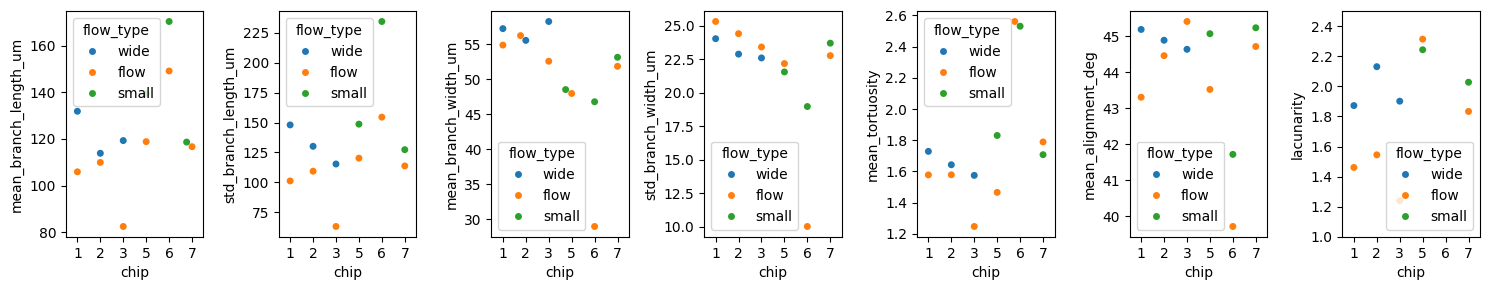

In [23]:
fig, ax = plt.subplots(ncols =7, figsize = (15,3))
sns.swarmplot(data = summary_df, x= "chip" , y="mean_branch_length_um", hue="flow_type", ax = ax[0])

sns.swarmplot(data = summary_df, x= "chip" , y="std_branch_length_um", hue="flow_type", ax = ax[1])
sns.swarmplot(data = summary_df, x= "chip" , y="mean_branch_width_um", hue="flow_type", ax = ax[2])
sns.swarmplot(data = summary_df, x= "chip" , y="std_branch_width_um", hue="flow_type", ax = ax[3])
sns.swarmplot(data = summary_df, x= "chip" , y="mean_tortuosity", hue="flow_type", ax = ax[4])
sns.swarmplot(data = summary_df, x= "chip" , y="mean_alignment_deg", hue="flow_type", ax = ax[5])
sns.swarmplot(data = summary_df, x= "chip" , y="lacunarity", hue="flow_type", ax = ax[6])
ax[-1].set_ylim(1,2.5)
plt.tight_layout()

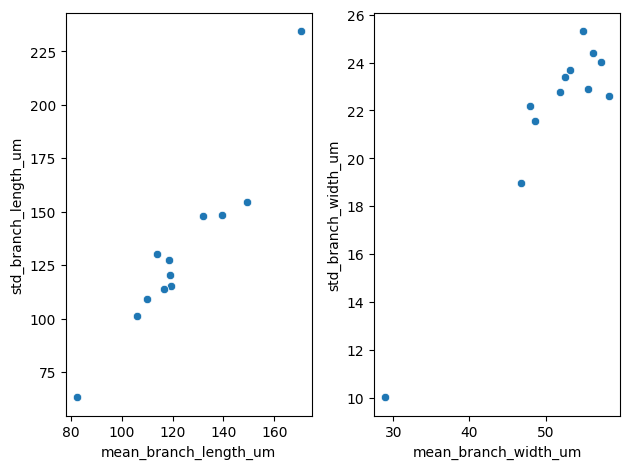

In [20]:
fig, ax = plt.subplots(ncols = 2)
sns.scatterplot(data = summary_df, x= "mean_branch_length_um", y = "std_branch_length_um", ax=ax[0])
sns.scatterplot(data = summary_df, x= "mean_branch_width_um", y = "std_branch_width_um", ax=ax[1])
plt.tight_layout()